In [41]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack
from astropy.io import ascii
from HMXB_pipeline_class import pipeline
import astropy.coordinates as coords
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import corner
from datetime import datetime
import os
from astropy.io.votable import parse
import emcee

In [42]:
from Galactic_traceback import GalacticTraceback
from Galactic_traceback_for_MCMC import galactic_path_MCMC as gpMCMC

In [43]:
cwd = os.getcwd()
cwd
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [44]:
HMXB_table = ascii.read(csv_files+'HMXB_20250505_.ecsv',format='ecsv')

In [45]:
HMXB_table['Name']

X Per
EXO 051910+3737.7
RX J0440.9+4431
XTE J0421+560
EM* AS 14
gam Cas
IGR J00370+6122
V 0332+53
Swift J0243.6+6124
LS I+61 303
RX J0146.9+6121


# Names
## GX 301-2, BP Crux, 3U 1223-62

In [46]:
BP_crux = HMXB_table[HMXB_table['source_id'] == 6054569565614460800]
BP_crux

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
6054569565614460800,186.65645139154256,0.012048252,-62.77035949368261,0.013341482,-5.226856654124623,0.015758464,-2.0707848986747575,0.018766105,0.25062115141915803,0.015989607,--,--,9.751056,300.0980601666885,-0.03521279949727996,0.9085312,3.5460981,3.3819047999999996,3.7297097,GX 301-2,--,--,43.0,10.0,4.1,2.4,41.498,0.002,680.0,--,3.9900862091544833,-5.027520170392972,-2.5163905729512837,7.0718444057591805,238.16461834201277,-235.6093982448917,-0.9616540188481638,-0.451919775766423,6.354960220074714,-5.957145610882443,-0.0012170923377336715,-28.883493976075155,47.04566283205356,26.628533756000436,1.8912794593376354,-2.0632537048471273,54.05897891471611,0.2545671457391046,B1 Ia+,xkcd:red,xkcd:red,0.015781623344754924,0.007798047397622519,0.01196558527448876,0.005891278677479887,7.648398746667116,10.06805110164379


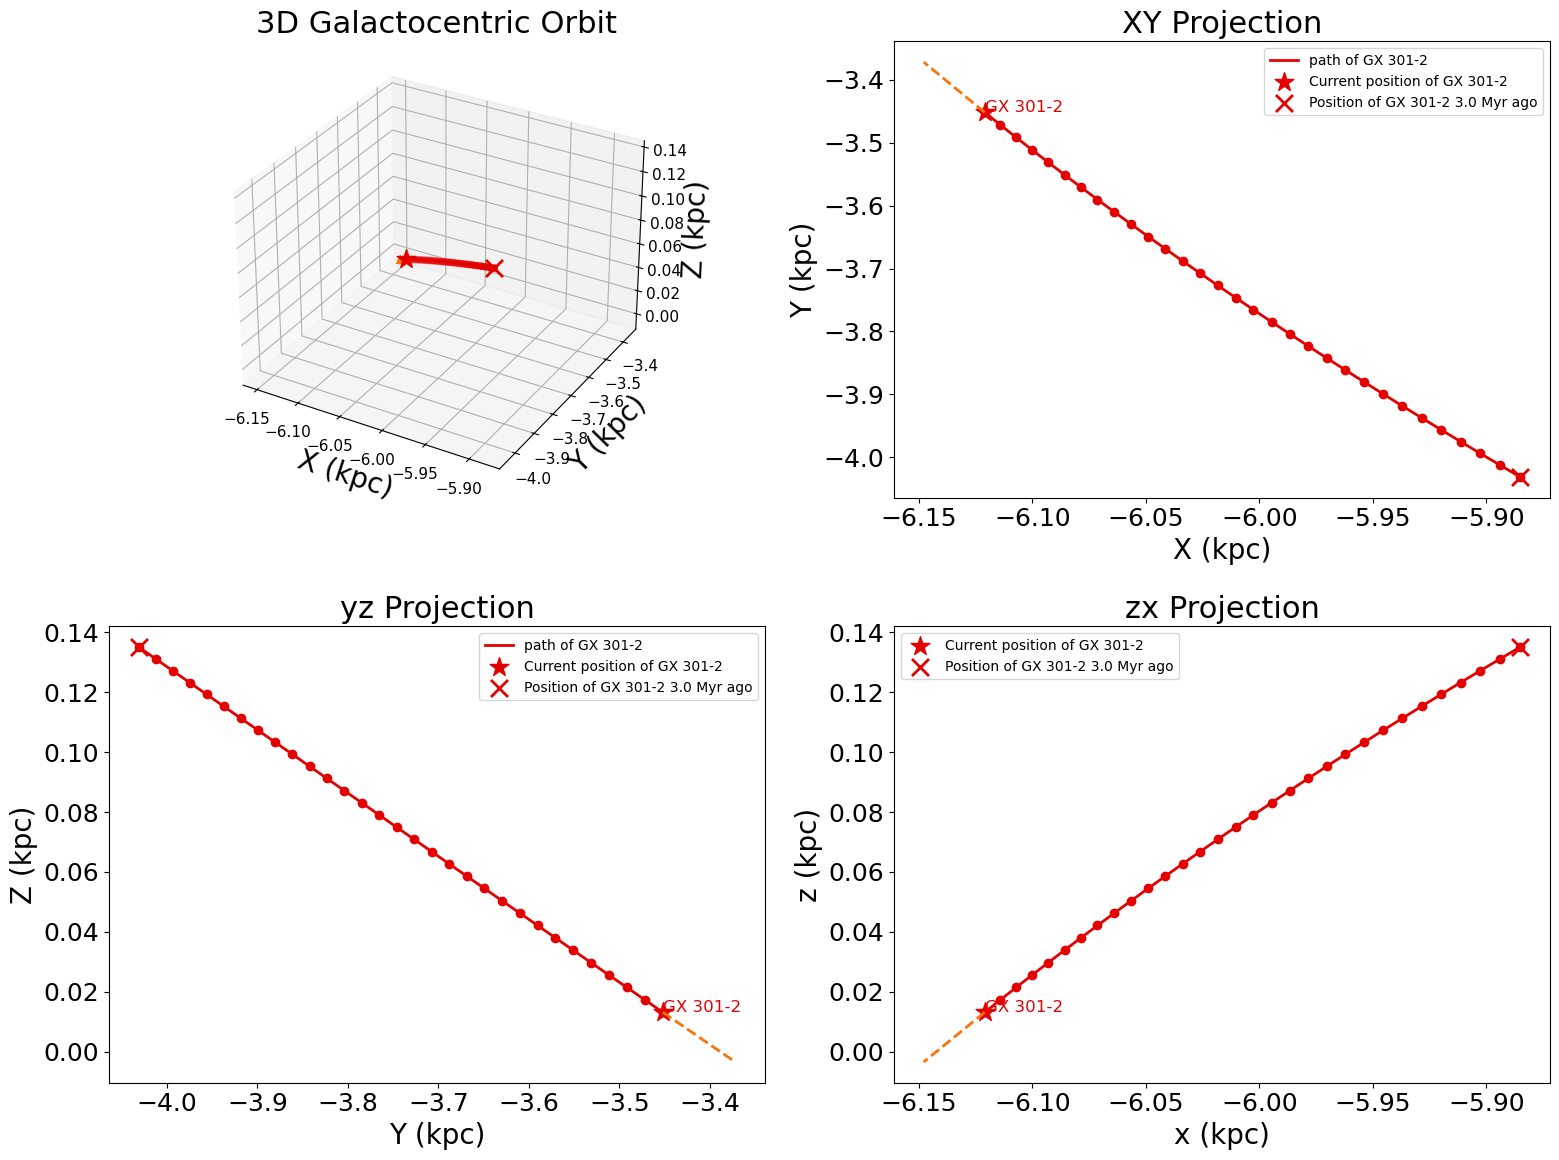

In [47]:
GalacticTraceback(BP_crux,int_time=-3.0).plot_in_galactocentric(BP_crux,cluster=None,figname=None,savefig=False)

In [48]:
from astropy.io.votable import parse

# Replace with your file path
votable = parse(csv_files+"Lower_cen_crux")

# Access the first table in the VOTable file
lower_crux_members = votable.get_first_table().to_table()



In [49]:
#lower_crux_members.colnames

In [50]:
lcm_filtered = Table(lower_crux_members['Distance_distance','Distance_unit','RA_d', 'DEC_d','PMRA','PMDEC','PLX_plx'])
lcm_filtered

Distance_distance,Distance_unit,RA_d,DEC_d,PMRA,PMDEC,PLX_plx
,,deg,deg,mas / yr,mas / yr,mas
float64,str4,float64,float64,float64,float64,float32
125.0590,pc,177.80473664,-43.93305699,-32.057,-9.661,7.996200
94.9690,pc,199.37063865,-42.93297386,-40.275,-23.152,10.529700
94.9690,pc,199.37063865,-42.93297386,-40.275,-23.152,10.529700
33.2970,pc,165.20942688,-49.01983727,-96.560,-60.304,30.032400
105.9490,pc,164.12289643,-48.33201636,-34.177,-4.431,9.438500
83.4560,pc,149.99020692,-72.36312088,-28.017,29.047,11.982400
102.4360,pc,132.52270256,-75.91057845,-16.698,32.513,9.762000
110.2980,pc,138.87137257,-76.14642495,-29.358,20.472,9.068000


In [51]:
print(np.unique(lcm_filtered['Distance_unit']))

Distance_unit
-------------
             
           pc


In [54]:
crux_ra = np.average(lcm_filtered['RA_d'])
crux_dec = np.average(lcm_filtered['DEC_d'])
crux_pmra = np.average(lcm_filtered['PMRA'])
crux_pmdec = np.average(lcm_filtered['PMDEC'])

crux_parallax = np.average(lcm_filtered['PLX_plx'])


np.float64(114.59063781547)

In [55]:

lower_crux_params = Table(data=[['Lower Crux'],[-6.7*u.km/u.s],[crux_ra*u.deg],[crux_dec*u.deg],[-6.34*u.mas/u.yr],[-0.88*u.mas/u.yr],[crux_parallax*u.mas],[(1/crux_parallax)*u.kpc],], names=['Name','RV',
                                                                                                                                     'ra','dec','pmra',
                                                                                  'pmdec','parallax','distance_bj'])
lower_crux_params

Name,RV,ra,dec,pmra,pmdec,parallax,distance_bj
,km / s,deg,deg,mas / yr,mas / yr,mas,kpc
str10,float64,float64,float64,float64,float64,float64,float64
Lower Crux,-6.7,192.55927052056174,-55.34986372675974,-6.34,-0.88,8.726716414741848,0.11459063781547


In [37]:
crux_ob1_params

Name,RV,ra,dec,pmra,pmdec,parallax,distance_bj
,km / s,deg,deg,mas / yr,mas / yr,mas,kpc
str8,float64,float64,float64,float64,float64,float64,float64
Crux OB1,-5.7,174.99,-62.81,-6.28,-0.86,0.49751243781094534,2.01


In [56]:
Simbad.query_object('LCC')
LLC_skycoord = SkyCoord(l=298 * u.deg,
    b=+5.0 * u.deg,
    pm_l_cosb=-6.28 * u.mas / u.yr,
    pm_b=-0.88 * u.mas / u.yr,frame="galactic")
LLC_icrs = LLC_skycoord.transform_to('icrs')

In [57]:
LLC_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (183.68244982, -57.51981219)
 (pm_ra_cosdec, pm_dec) in mas / yr
    (-6.34131178, 0.0237671)>

In [58]:
LLC_skycoord

<SkyCoord (Galactic): (l, b) in deg
    (298., 5.)
 (pm_l_cosb, pm_b) in mas / yr
    (-6.28, -0.88)>

In [17]:
BP_crux

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
6054569565614460800,186.65645139154256,0.012048252,-62.77035949368261,0.013341482,-5.226856654124623,0.015758464,-2.0707848986747575,0.018766105,0.25062115141915803,0.015989607,--,--,9.751056,300.0980601666885,-0.03521279949727996,0.9085312,3.5460981,3.3819047999999996,3.7297097,GX 301-2,--,--,43.0,10.0,4.1,2.4,41.498,0.002,680.0,--,3.9900862091544833,-5.027520170392972,-2.5163905729512837,7.0718444057591805,238.16461834201277,-235.6093982448917,-0.9616540188481638,-0.451919775766423,6.354960220074714,-5.957145610882443,-0.0012170923377336715,-28.883493976075155,47.04566283205356,26.628533756000436,1.8912794593376354,-2.0632537048471273,54.05897891471611,0.2545671457391046,B1 Ia+,xkcd:red,xkcd:red,0.015781623344754924,0.007798047397622519,0.01196558527448876,0.005891278677479887,7.648398746667116,10.06805110164379


In [18]:
lcm_members = lcm_filtered
lcm_members.rename_columns(['Distance_distance','RA_d',	'DEC_d','PMRA',	'PMDEC','PLX_plx'], ['distance_bj','ra','dec','pmra','pmdec','parallax'])

In [19]:
lcm_members

distance_bj,Distance_unit,ra,dec,pmra,pmdec,parallax
,,deg,deg,mas / yr,mas / yr,mas
float64,str4,float64,float64,float64,float64,float32
125.0590,pc,177.80473664,-43.93305699,-32.057,-9.661,7.996200
94.9690,pc,199.37063865,-42.93297386,-40.275,-23.152,10.529700
94.9690,pc,199.37063865,-42.93297386,-40.275,-23.152,10.529700
33.2970,pc,165.20942688,-49.01983727,-96.560,-60.304,30.032400
105.9490,pc,164.12289643,-48.33201636,-34.177,-4.431,9.438500
83.4560,pc,149.99020692,-72.36312088,-28.017,29.047,11.982400
102.4360,pc,132.52270256,-75.91057845,-16.698,32.513,9.762000
110.2980,pc,138.87137257,-76.14642495,-29.358,20.472,9.068000


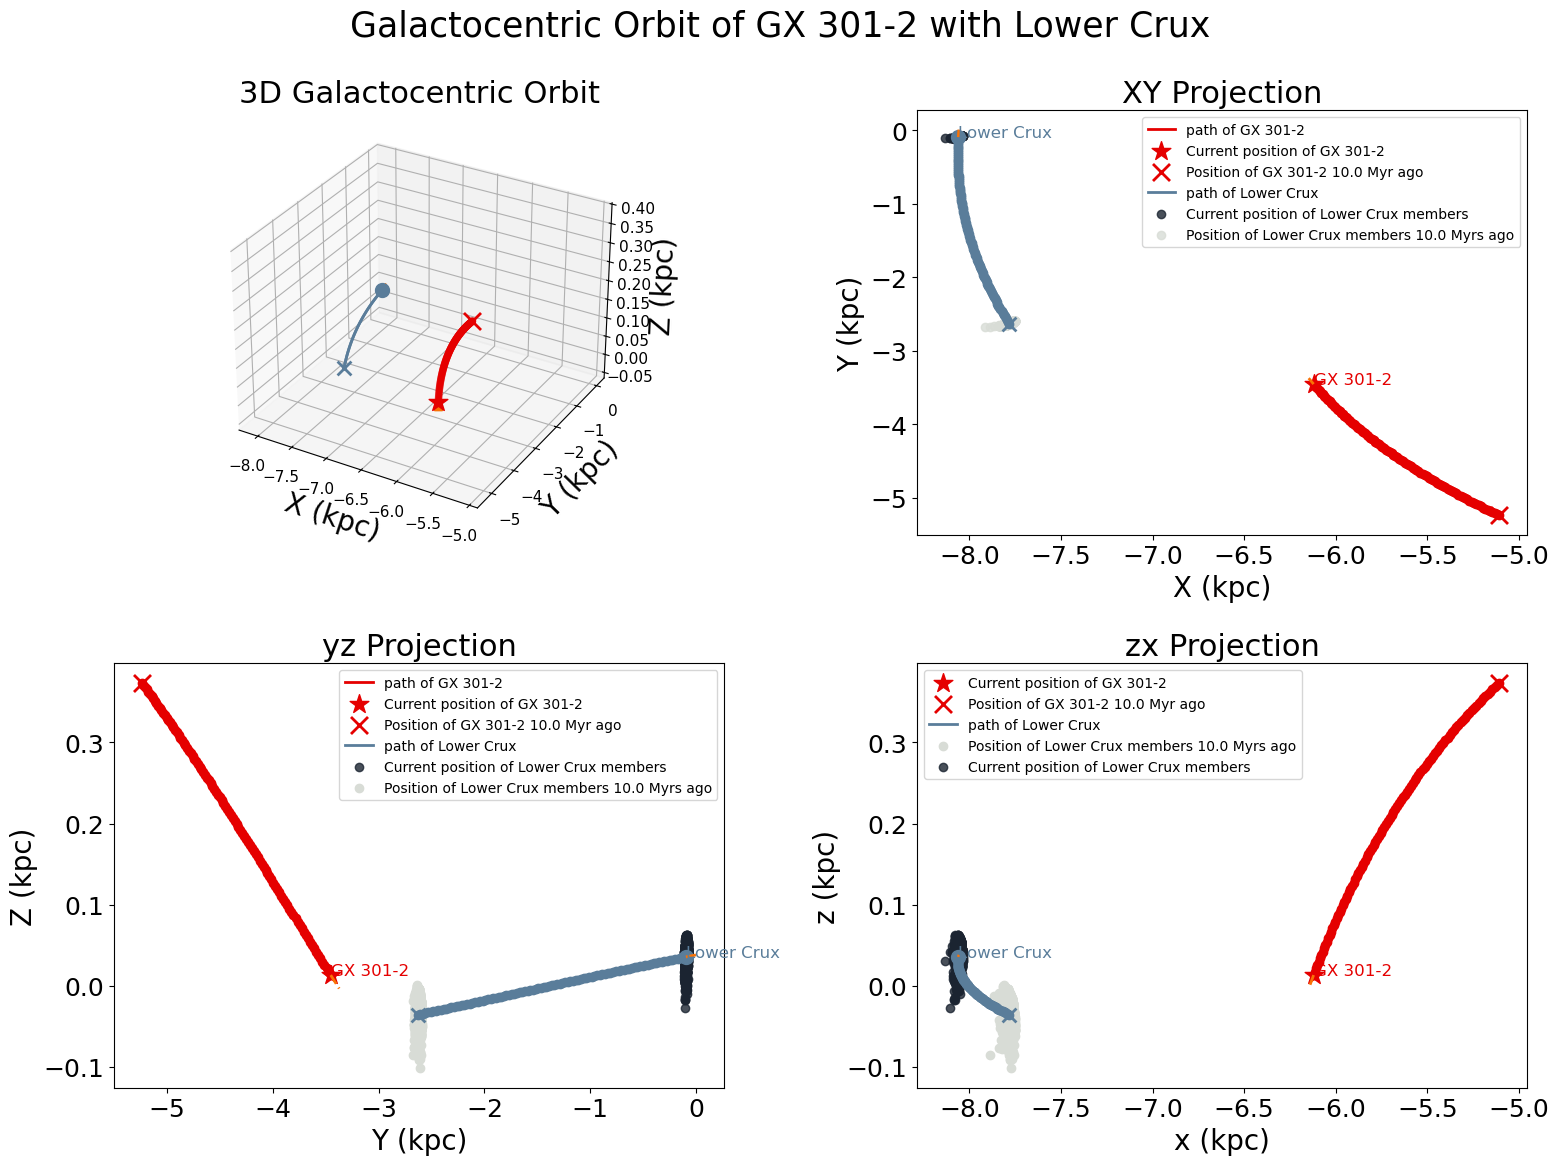

In [59]:
GalacticTraceback(BP_crux,int_time=-10.0).plot_in_galactocentric(BP_crux,cluster=lower_crux_params,cluster_members=lcm_members,figname=None,savefig=False)

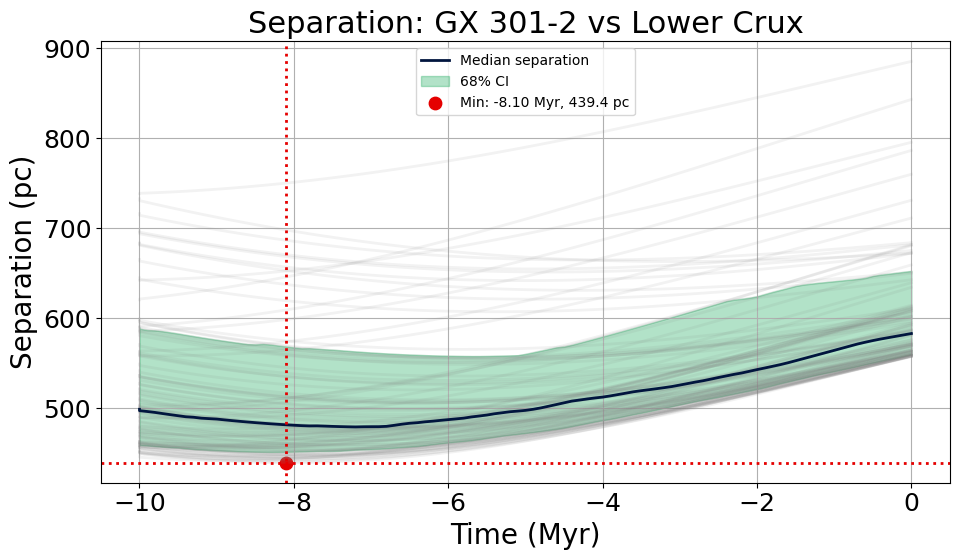

In [21]:
GalacticTraceback(BP_crux,int_time=-10.0).plot_separation_with_uncertainty(BP_crux,cluster=lower_crux_params,savefig=False)

# BP CRUX with CRUX OB1
Mel'nik 2017

In [34]:
crux_ob1_galactic = SkyCoord(l=294.87*u.deg, b=-1.06*u.deg,pm_l_cosb = -6.28*u.mas/u.yr, pm_b = -0.88*u.mas/u.yr, radial_velocity=-5.3*u.km/u.s,frame='galactic')

crux_ob1_icrs = crux_ob1_galactic.transform_to(coords.ICRS)
crux_ob1_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (174.99063473, -62.80760354)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-6.2815709, 0.86871576, -5.3)>

In [35]:
crux_ob1_params = Table(data=[['Crux OB1'],[-5.7*u.km/u.s],[174.99*u.deg],[-62.81*u.deg],[-6.28*u.mas/u.yr],[-0.86*u.mas/u.yr],[(1/2.01)*u.mas],[2.01*u.kpc],], names=['Name','RV',
                                                                                                                                     'ra','dec','pmra',
                                                                                  'pmdec','parallax','distance_bj'])

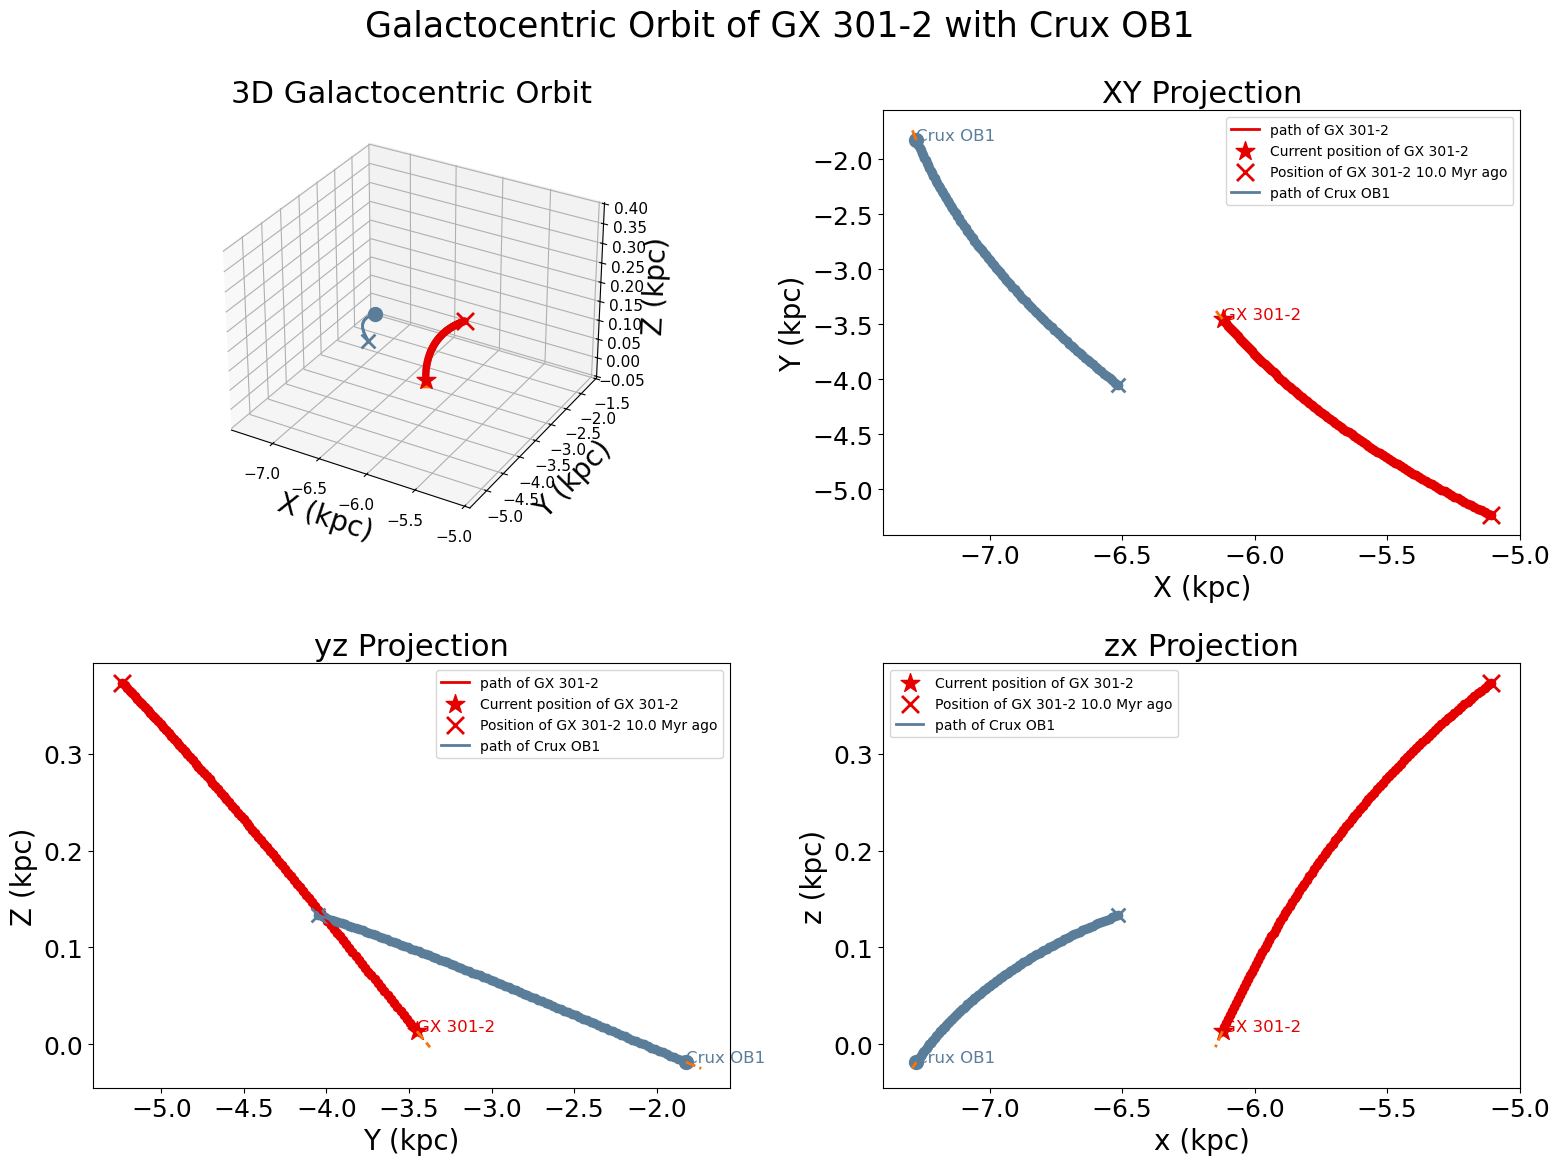

In [36]:
GalacticTraceback(BP_crux,int_time=-10.0).plot_in_galactocentric(BP_crux,cluster=crux_ob1_params,cluster_members=None,figname=None,savefig=False)

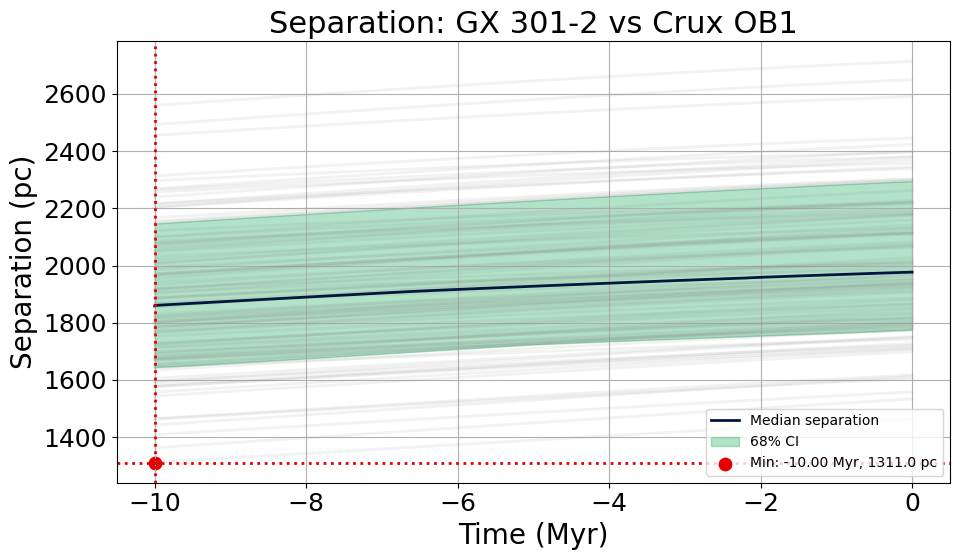

In [39]:
GalacticTraceback(BP_crux,int_time=-10.0).plot_separation_with_uncertainty(BP_crux,cluster=crux_ob1_params,savefig=False)

# From Fortin et al 2022, encounter with IGR J17544-2619
## and UBC 571

In [22]:
IGR17 = HMXB_table[HMXB_table['Name'] == 'IGR J17544-2619']
IGR17

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
4063908810076415872,268.6052987030251,0.022245996,-26.331274336947732,0.017260587,-0.5057220749359188,0.028629052,-0.667794468304362,0.018198028,0.3963276780006648,0.026676178,--,--,11.663726,3.235979885614684,-0.33555745740311615,1.0879679,2.3734287,2.2324102,2.5326438,IGR J17544-2619,1.4,--,23.0,2.0,-46.8,4.0,4.92693,0.00036,71.49,0.02,2.5231646829326984,-0.8314110047136792,0.10227419135044297,5.7819487124757405,236.29568305842508,18.679952326802262,-1.152765456344392,-0.6815537902937753,-11.505771041838011,-0.006862123644544323,0.0028525748668439465,3.8873977689401538,9.530385860637507,-39.18162672710214,0.32821657527525716,0.7809754067773742,40.32403907887458,0.1698301528941027,O9Ib,xkcd:blue,xkcd:blue,0.015452913265764581,0.008701383308186405,0.01475645890990641,0.008389885147851035,16.12799998226518,68.63317490846346


In [23]:
Simbad.query_object('UBC 571')

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,matched_id
,deg,deg,mas,mas,deg,,,
object,float64,float64,float32,float32,int16,str1,object,object
UBC 571,267.346,-29.574,--,--,--,O,2021A&A...647A..19T,UBC 571


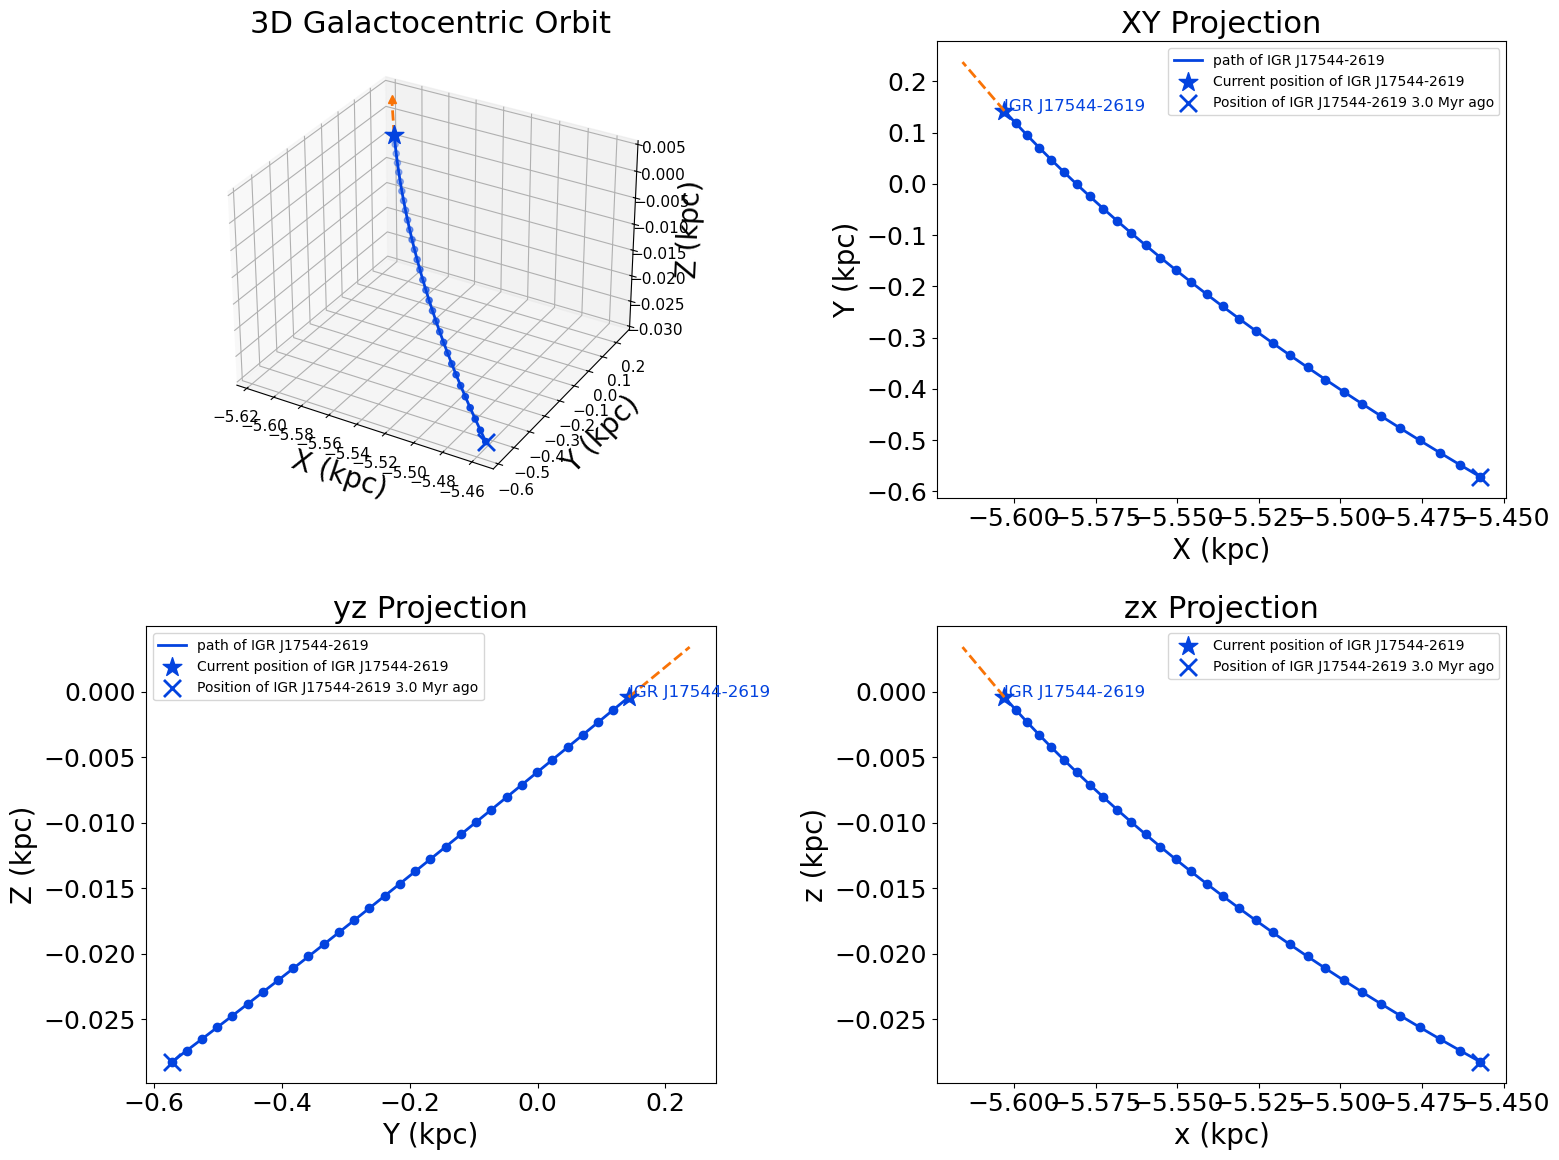

In [25]:
GalacticTraceback(IGR17,int_time=-3.0).plot_in_galactocentric(IGR17,cluster=None,figname=None,savefig=False)

# UBC 571

https://www.aanda.org/articles/aa/full_html/2021/03/aa39388-20/aa39388-20.html

In [67]:
UBC571_params = Table(data=[['UBC 571'],[-21.470*u.km/u.s],[267.346*u.deg],[-29.574*u.deg],[-1.0900*u.mas/u.yr],[-2.8930*u.mas/u.yr],[0.354*u.mas],[(1/0.354)*u.kpc]], 
                      names=['Name','RV','ra','dec','pmra','pmdec','parallax','distance_bj']) 
UBC571_params

Name,RV,ra,dec,pmra,pmdec,parallax,distance_bj
,km / s,deg,deg,mas / yr,mas / yr,mas,kpc
str7,float64,float64,float64,float64,float64,float64,float64
UBC 571,-21.47,267.346,-29.574,-1.09,-2.893,0.354,2.824858757062147


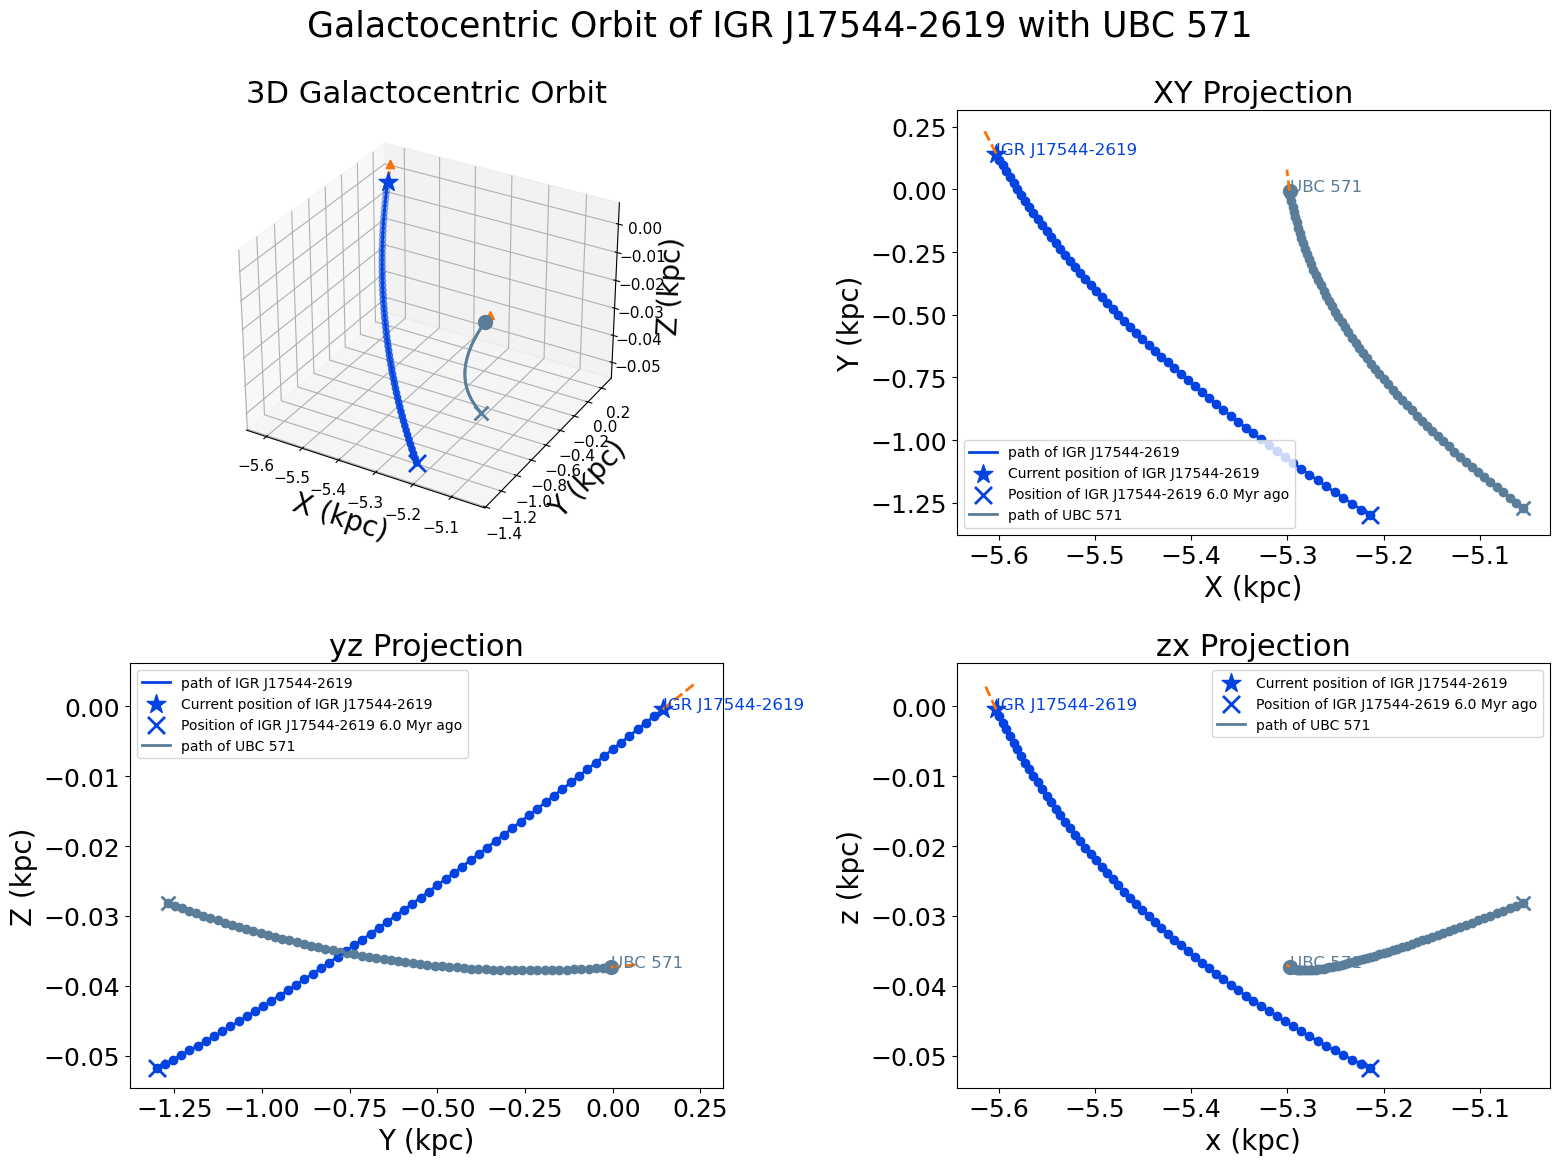

In [68]:
GalacticTraceback(IGR17,int_time=-6.0).plot_in_galactocentric(IGR17,cluster=UBC571_params,figname=None,savefig=False)

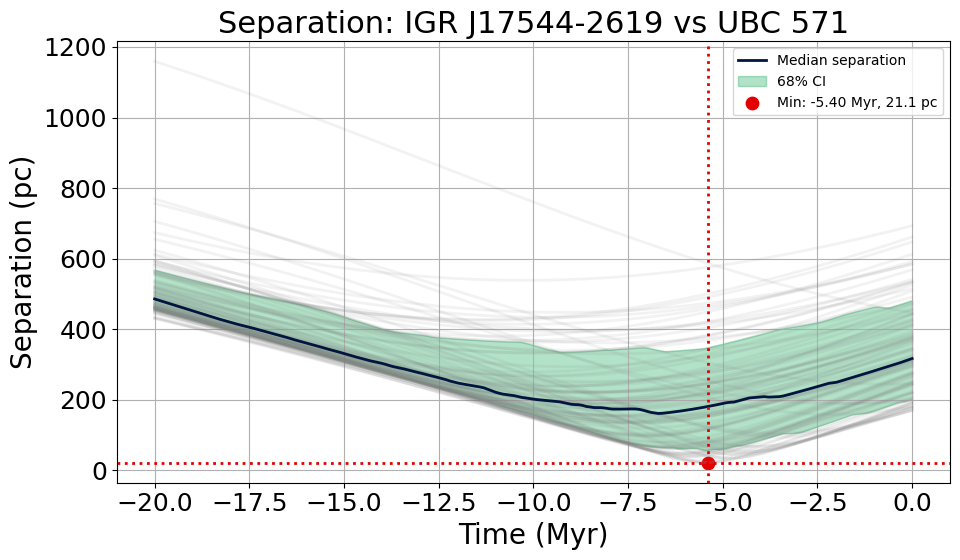

In [62]:
GalacticTraceback(IGR17,int_time= -20).plot_separation_with_uncertainty(IGR17,cluster=UBC571_params
                                                                         ,savefig=False)

In [63]:
names_x = ['IGR17','UBC 571']
gpmc_args = {'backend_name':'IGR17_UBC571_chain','star_params':IGR17,'cluster_params':UBC571_params, 'cluster_radius':None,'int_time':-10.0,
            'names':names_x}

In [30]:
#sample_igr17, state_igr17 = gpMCMC().start_mcmc(**gpmc_args)

In [64]:
backend_igr17 = emcee.backends.HDFBackend('IGR17_UBC571_chain.h5')

In [65]:
chain_igr17 = backend_igr17.get_chain(thin=10, flat=True)
blobs_igr17 = backend_igr17.get_blobs(thin=10,flat=True)
kinematic_ages = np.array([b[0] for b in blobs_igr17])
min_separations = np.array([b[1] for b in blobs_igr17])

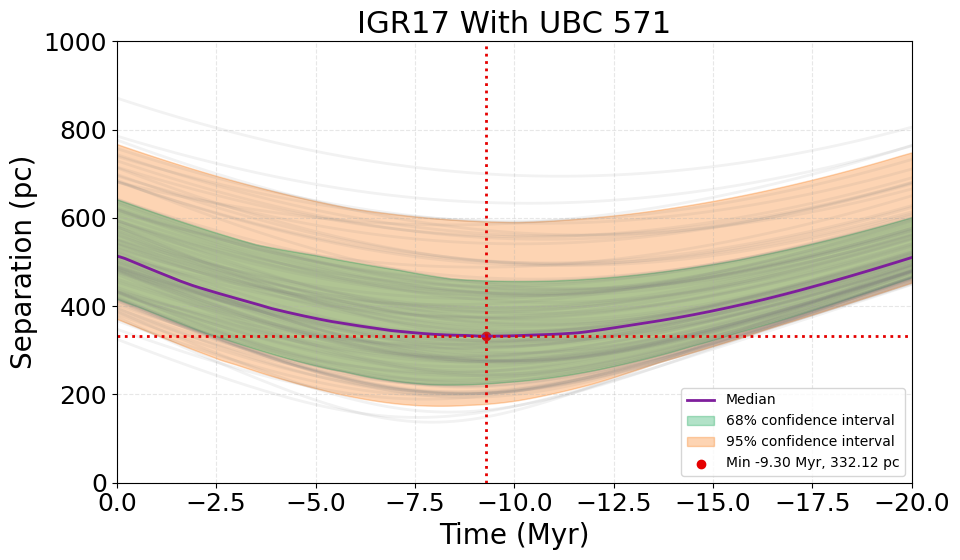

In [71]:
gpMCMC().compute_full_separations_and_plot(flat_chain=chain_igr17, cluster_params=UBC571_params, int_time=-20.0, star_ra=IGR17['ra'], 
                                  star_dec=IGR17['dec'],
                                  cluster_radius=None, title='IGR17 With UBC 571',
                                  n_samples=100)